# Session 1: Data Basics and Descriptive Statistics

Welcome to the first session of the Data Analysis workshop for Complex Systems course.


---

## 1. What is Data?

In scientific computing, **data** is a collection of observations or measurements of one or more variables. 

Mathematically, a single variable dataset with $n$ observations is represented as a **vector**:
$$ \mathbf{x} = [x_1, x_2, x_3, \dots, x_n] $$

In Python, we use **NumPy arrays** to represent these vectors because they allow for **vectorized operations** (applying math to the whole list at once without loops).

## 2. Types of Data

Before calculating anything, we must identify the nature of our data:

1. **Numerical Data**:
   - **Continuous**: Real values.
   - **Discrete**: Countable integers.
2. **Categorical Data**:
   - Labels or classes.



In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style="whitegrid")


## 3. Working with Vector Data

Before we define statistics, let's see how Python handles data vectors using NumPy. 
Unlike standard Python lists, NumPy arrays allow for **element-wise** math.


In [33]:
data = np.array([10, 12, 23, 23, 16, 23, 21, 16])

print(f"data: {data}")
print(f" + 10: {data + 10}")
print(f"Vector sqrt: {data**2}")


data: [10 12 23 23 16 23 21 16]
 + 10: [20 22 33 33 26 33 31 26]
Vector sqrt: [100 144 529 529 256 529 441 256]


## 4. Descriptive Statistics (The Moments)

To summarize a large dataset, we use **summary statistics**. In probability theory, many of these statistics are connected to the **moments** of a distribution.

Moments describe important properties of data such as location, spread, asymmetry, and tail behavior.

In general, the **k-th moment** of a a variable can be defined in two ways.

### General Definition of Moments




**Discrete form (data):**

$$
m_k = \frac{1}{n} \sum_{i=1}^{n} x_i^k
$$

**Continuous form (probability distribution):**

$$
m_k = \int_{-\infty}^{\infty} x^k f(x)\,dx
$$

where $f(x)$ is the **probability density function (PDF)**.

---
The **k-th central moment** is defined relative to the mean.

$$
\text{k-th moment} =
\left\langle
\left(
\frac{x-\mu}{\sigma}
\right)^k
\right\rangle
$$

#### Discrete form

$$
\mu_k = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^k
$$

#### Continuous form

$$
\mu_k = \int_{-\infty}^{\infty} (x - \mu)^k f(x)\,dx
$$

---

### 4.0 Zeroth Moment

The **zeroth moment** represents the total probability.

Discrete case:

$$
m_0 = \frac{1}{n}\sum_{i=1}^{n} 1 = 1
$$

Continuous case:

$$
\int_{-\infty}^{\infty} f(x)\,dx = 1
$$

This expresses the fundamental rule that **total probability equals 1**.

---

### 4.1 The First Moment: Mean ($ \mu $)

The **first moment** represents the **center (expected value)** of the distribution.

Discrete form:

$$
\mu = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

Continuous form:

$$
\mu = \int_{-\infty}^{\infty} x\,f(x)\,dx
$$

---

### 4.2 The Median

The **median** is the middle value of a sorted dataset.  
It divides the observations so that **50% of the data lies below it and 50% above it**.

Unlike the mean, the median is **robust to outliers**.


#### Discrete definition

Let the data be sorted:

$$
x_{(1)} \le x_{(2)} \le \dots \le x_{(n)}
$$

If $n$ is odd:

$$
\text{median} = x_{\left(\frac{n+1}{2}\right)}
$$

If $n$ is even:

$$
\text{median} =
\frac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}}{2}
$$

#### Continuous definition

The median $ m $ satisfies

$$
\int_{-\infty}^{m} f(x)\,dx = 0.5
$$

meaning that half of the probability mass lies on each side.


In [34]:
data = np.array([10, 12, 23, 23, 16, 23, 21, 16,16])


def get_mean(x):
    return sum(x) / len(x)

def get_median(x):
    sorted_x = sorted(x)
    n = len(sorted_x)
    mid = n // 2
    if n % 2 == 0:
        return (sorted_x[mid-1] + sorted_x[mid]) / 2
    else:
        return sorted_x[mid]

print(f"Data: {data}")
print(f" Mean: {get_mean(data)}")
print(f" Median: {get_median(data)}")
print(f" Median: {np.median(data)}")
print(f" Median: {np.mean(data)}")



Data: [10 12 23 23 16 23 21 16 16]
 Mean: 17.77777777777778
 Median: 16
 Median: 16.0
 Median: 17.77777777777778


### 4.3 The Second Moment: Variance ($\sigma^2$) and Standard Deviation ($\sigma$)
*centerized*

Variance measures the **spread** or **dispersion** of the data around the mean. 

---

#### Discrete form

$$
\text{var} =
\left\langle
\left(
x-\mu
\right)^2
\right\rangle = \left\langle
x^2 \right\rangle - \left\langle x \right\rangle^ 2
$$

$$
\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2
$$
---

#### Continuous form

$$
\sigma^2 = \int_{-\infty}^{\infty} (x - \mu)^2 f(x)\,dx
$$

---

Standard Deviation is simply the square root of variance, bringing the units back to the original scale:

$$
\sigma = \sqrt{\sigma^2}
$$

In [35]:
def get_variance(x):
    mu = get_mean(x)
    return sum((f - mu)**2 for f in x) / len(x)

def get_std(x):
    return get_variance(x)**0.5

print(f" Variance: {get_variance(data)}")
print(f" Std Dev: {get_std(data)}")
print(f" Std Dev: {np.var(data)}")

 Variance: 21.728395061728396
 Std Dev: 4.661372658534007
 Std Dev: 21.728395061728392


### 4.4 Higher Moments: Skewness and Kurtosis

Higher moments describe more subtle properties of a distribution such as **asymmetry** and **tail behavior**.


### Skewness (\(k=3\))

Skewness measures the **asymmetry** of the distribution.

- **Positive skew** → long tail to the right  
- **Negative skew** → long tail to the left  

$$
\text{Skewness} =
\left\langle
\left(
\frac{x-\mu}{\sigma}
\right)^3
\right\rangle
$$

 
#### Discrete form

$$
\text{Skewness} =
\frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i-\mu}{\sigma}\right)^3
$$

#### Continuous form

$$
\text{Skewness} =
\int_{-\infty}^{\infty}
\left(\frac{x-\mu}{\sigma}\right)^3 f(x)\,dx
$$

---

### Kurtosis ($k=4$)

Kurtosis measures the **tailedness** or **peakedness** of a distribution.

Higher kurtosis indicates **heavier tails** and more extreme values.

Often we use **excess kurtosis**, defined as

$$
\text{Kurtosis} =
\left\langle
\left(
\frac{x-\mu}{\sigma}
\right)^4
\right\rangle - 3
$$

The subtraction of **3** ensures that a **Gaussian (normal) distribution has kurtosis = 0**.

#### Discrete form

$$
\text{Kurtosis} =
\frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i-\mu}{\sigma}\right)^4
$$

#### Continuous form

$$
\text{Kurtosis} =
\int_{-\infty}^{\infty}
\left(\frac{x-\mu}{\sigma}\right)^4 f(x)\,dx
$$


In [ ]:
def get_skewness(x):
    mu = get_mean(x)
    sigma = get_std(x)
    return sum(((xi - mu) / sigma)**3 for xi in x) / len(x)


print(f" Skewness: {get_skewness(data)}")
print(f" 2Skewness: {stats.skew(data)}")



 Skewness: -0.24083056480064124
 2Skewness: -0.24083056480064144


In [37]:
def get_kurtosis_raw(x):
    mu = get_mean(x)
    sigma = get_std(x)
    return sum(((xi - mu) / sigma)**4 for xi in x) / len(x)

print(f" Kurtosis raw: {get_kurtosis_raw(data)}")
print(f" 2Skewness: {stats.skew(data)}")


 Kurtosis raw: 1.681034349173554
 2Skewness: -0.24083056480064144


In [38]:
def get_kurtosis(x):
    return get_kurtosis_raw (x) - 3

print(f" Kurtosis: {get_kurtosis(data)}")


 Kurtosis: -1.318965650826446


## 5. Validation Using Gaussian Data

The **standard normal distribution** $\mathcal{N}(0,1)$ has known theoretical values:

| Statistic | Theoretical Value |
|-----------|-------------------|
| Mean      | 0                 |
| Median    | 0                 |
| Variance  | 1                 |
| Std Dev   | 1                 |
| Skewness  | 0                 |
| raw Kurtosis | 3           |
| Kurtosis | 0           |

Let's generate a large Gaussian sample and verify our manual functions.

In [ ]:
N = 200000
gaussian_data = np.random.normal(loc=0, scale=1, size=N)


print("=== Manual Functions ===")
print(f"Mean: {get_mean(gaussian_data):.5f}")
print(f"median: {get_median(gaussian_data):.5f}")

print(f"Variance: {get_variance(gaussian_data):.5f}")
print(f"Std Dev: {get_std(gaussian_data):.5f}")
print(f"Skewness: {get_skewness(gaussian_data):.5f}")
print(f"Excess Kurtosis: {get_kurtosis(gaussian_data):.5f}")


print("\n=== built-in Verification ===")
print(f"Mean: {np.mean(gaussian_data):.5f}")
print(f"median: {np.median(gaussian_data):.5f}")

print(f"Variance: {np.var(gaussian_data,ddof=1):.5f}")
print(f"Variance: {np.std(gaussian_data):.5f}")

print(f"Skewness (scipy): {stats.skew(gaussian_data, bias=False):.05f}")
print(f"Excess Kurtosis (scipy): {stats.kurtosis(gaussian_data, fisher=True, bias=True):.5f}")

=== Manual Functions ===
Mean: 0.00198
median: 0.00084
Variance: 1.00296
Std Dev: 1.00148
Skewness: 0.00747
Excess Kurtosis: 0.00157

=== built-in Verification ===
Mean: 0.00198
median: 0.00084
Variance: 1.00297
Variance: 1.00148
Skewness (scipy): 0.00747
Excess Kurtosis (scipy): 0.00157


## compensatory:
 Wrap the above code in a loop over increasing sample sizes (or repeated simulations) to empirically verify that the sample moments converge to the theoretical Gaussian values (mean=0, variance=1, skewness=0, excess kurtosis=0), thereby illustrating the Law of Large Numbers, ergodicity, and the Central Limit Theorem.

## 6. Bivariate Statistics: Covariance and Correlation

How do two variables ($X$ and $Y$) move together?


**variance:**
$$
\text{var}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu_x)(x_i - \mu_x)
$$

**Covariance:**
$$
\text{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu_x)(y_i - \mu_y)
$$

**Pearson Correlation ($\rho$):**
$$
\rho = \frac{\text{Cov}(X, Y)}{\sigma_x \sigma_y} \quad \in [-1, 1]
$$

In [25]:
def get_covariance(x, y):
    if len(x) != len(y):
        return None
    mu_x, mu_y = get_mean(x), get_mean(y)
    return sum((x[i] - mu_x) * (y[i] - mu_y) for i in range(len(x))) / len(x)

def get_correlation(x, y):
    return get_covariance(x, y) / (get_std(x) * get_std(y))


x_test = np.array([1, 2, 3, 4, 5])
y_test = np.array([2, 4, 5, 4, 5])
print(f" Correlation: {get_correlation(x_test, y_test):.3f}")
print(f"NumPy Correlation: {np.corrcoef(x_test, y_test)[0,1]:.3f}")

 Correlation: 0.775
NumPy Correlation: 0.775


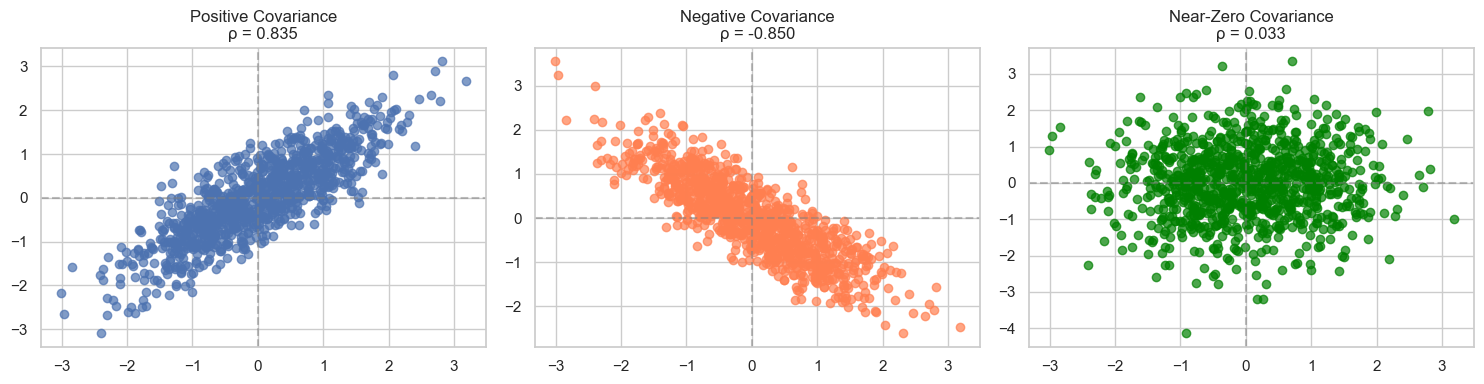

In [26]:
n = 1000

x = np.random.normal(0, 1, n)
y_pos = 0.8 * x + np.random.normal(0, 0.5, n)

y_neg = -0.8 * x + np.random.normal(0, 0.5, n)

y_zero = np.random.normal(0, 1, n)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(x, y_pos, alpha=0.7)
axes[0].set_title(f"Positive Covariance\nρ = {get_correlation(x, y_pos):.3f}")
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)

axes[1].scatter(x, y_neg, alpha=0.7, color='coral')
axes[1].set_title(f"Negative Covariance\nρ = {get_correlation(x, y_neg):.3f}")
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)

axes[2].scatter(x, y_zero, alpha=0.7, color='green')
axes[2].set_title(f"Near-Zero Covariance\nρ = {get_correlation(x, y_zero):.3f}")
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## compensatory:
 For the zero‑covariance plot, write a loop that repeatedly generates `x` and `y_zero` until `get_correlation(x, y_zero)` is within ±0.001 of 0. Record how many iterations it takes.

## 7. Empirical Cumulative Distribution Function (ECDF)

The **CDF** $F(x) = P(X \le x)$ gives the probability that a random variable is less than or equal to $x$.  
The **ECDF** is its empirical counterpart built directly from data.

***

### 1. Continuous Distributions

For a continuous random variable with **probability density function (PDF)** $f_X(t)$:

$$
F_X(x) = \int_{-\infty}^{x} f_X(t) \, dt
$$

**Interpretation:** The area under the PDF curve from $-\infty$ up to $x$.

---

### 2. Discrete Distributions

For a discrete random variable with **probability mass function (PMF)** $P(X = t)$:

$$
F_X(x) = \sum_{t \le x} P(X = t)
$$

**Interpretation:** Sum the probabilities of all outcomes less than or equal to $x$.

---



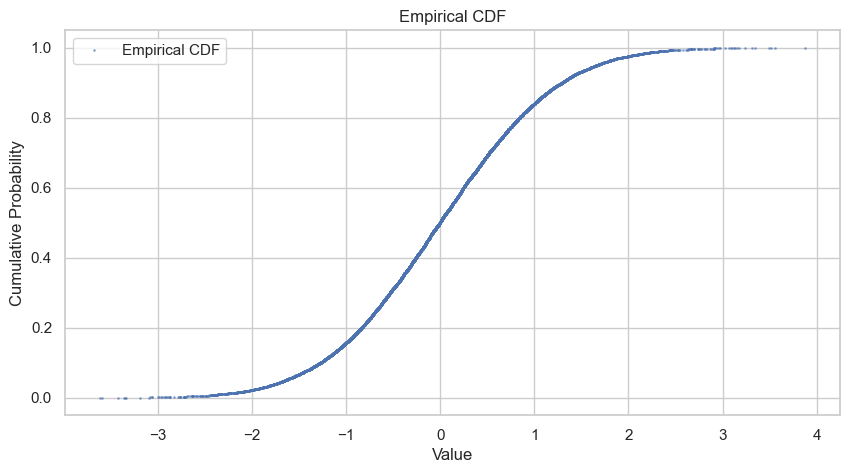

In [28]:
def ecdf(data):
    n = len(data)
    x = np.sort(data)
    y = np.arange(1, n+1) / n
    return x, y

N = 10000
gaussian_data = np.random.normal(loc=0, scale=1, size=N)

x_ecdf, y_ecdf = ecdf(gaussian_data)


plt.figure(figsize=(10,5))
plt.plot(x_ecdf, y_ecdf, marker='.', linestyle='none', markersize=2, alpha=0.5, label='Empirical CDF')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title('Empirical CDF')
plt.legend()
plt.show()

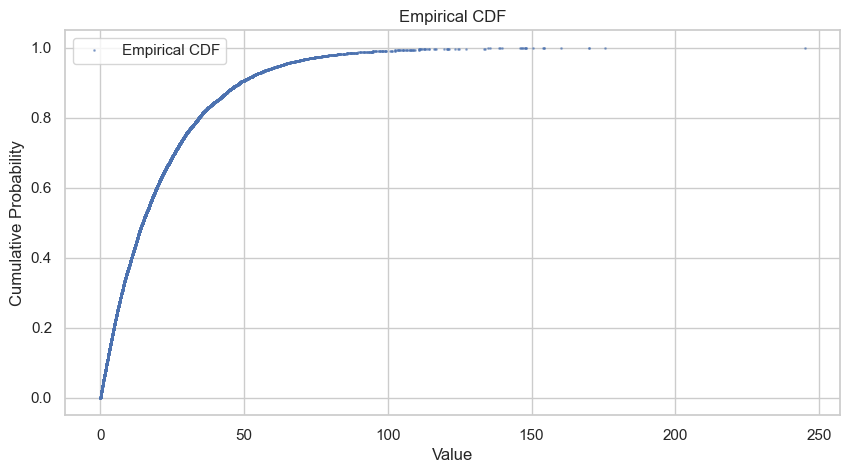

In [ ]:
def ecdf(data):
    n = len(data)
    x = np.sort(data)
    y = np.arange(1, n+1) / n
    return x, y

N = 10000
exp = np.random.exponential(loc=0, scale=1, size=N)

x_ecdf, y_ecdf = ecdf(exp)


plt.figure(figsize=(10,5))
plt.plot(x_ecdf, y_ecdf, marker='.', linestyle='none', markersize=2, alpha=0.5, label='Empirical CDF')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title('Empirical CDF')
plt.legend()
plt.show()

\* why -4 to 4?

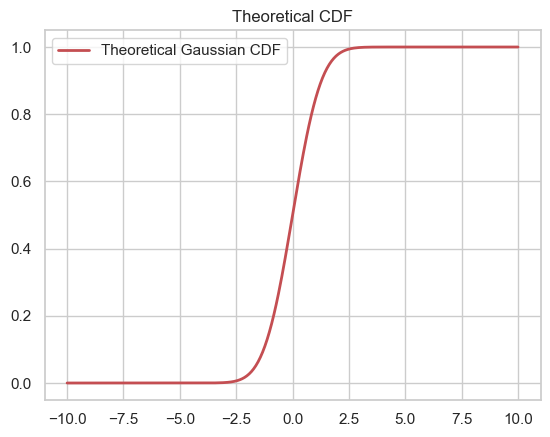

In [33]:
x_theor = np.linspace(-10, 10, 400)
cdf_theor = stats.norm.cdf(x_theor)
plt.plot(x_theor, cdf_theor, 'r-', linewidth=2, label='Theoretical Gaussian CDF')
plt.title('Theoretical CDF')
plt.legend()
plt.show()

Thanks.